1-Data Collection


In [30]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("student_social_media.csv")

# Independent variables
X = df[["Avg_Daily_Usage_Hours", "Sleep_Hours_Per_Night", 
        "Mental_Health_Score", "Conflicts_Over_Social_Media"]]

# Dependent variable
y = df["Addicted_Score"]

df.head()

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7


2-Data Cleaning


In [9]:
# Fill missing values ONLY for numeric columns
df = df.fillna(df.select_dtypes(include=['number']).mean())

# Remove duplicates
df = df.drop_duplicates()

3- Show the first rows


In [8]:
df.head()

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7


4-Check if duplicates were removed


In [13]:
df.shape

(705, 13)

5-Check missing values


In [11]:
df.isnull().sum()

Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Country                         0
Avg_Daily_Usage_Hours           0
Most_Used_Platform              0
Affects_Academic_Performance    0
Sleep_Hours_Per_Night           0
Mental_Health_Score             0
Relationship_Status             0
Conflicts_Over_Social_Media     0
Addicted_Score                  0
dtype: int64

6- Treating Categorical Variables


In [15]:
# Example if encoding was needed
df = pd.get_dummies(df, drop_first=True)

7-Splitting the Dataset


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

8-Featuring the Dataset


In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

9-Detecting & Removing Outliers (IQR Method)


In [23]:
numeric_cols = ["Avg_Daily_Usage_Hours", "Sleep_Hours_Per_Night",
                "Mental_Health_Score", "Conflicts_Over_Social_Media"]

Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

outlier_mask = ((df[numeric_cols] < (Q1 - 1.5 * IQR)) |
                (df[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)

# Count outliers
print("Number of outliers:", outlier_mask.sum())

# Remove outliers
df_clean = df[~outlier_mask].copy()

# Show new shape
df_clean.shape

Number of outliers: 3


(702, 133)

10 - Prepare X and Y 


In [24]:
X = df_clean[numeric_cols]
y = df_clean["Addicted_Score"]

X.head()   # SHOW RESULT

,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score,Conflicts_Over_Social_Media
0,5.2,6.5,6,3
1,2.1,7.5,8,0
2,6.0,5.0,5,4
3,3.0,7.0,7,1
4,4.5,6.0,6,2


11- Split the data


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape   # SHOW RESULT

((561, 4), (141, 4))

12- Scale the data 


In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled[:5]   # SHOW RESULT

array([[-0.01029499, -0.43559167, -1.12763391,  0.16734812],
       [ 1.59400714, -0.70198004, -1.12763391,  1.21048474],
       [ 0.06992012, -0.25799943, -0.22002613,  0.16734812],
       [-0.33115541,  0.45236955,  0.68758166,  0.16734812],
       [ 0.71164097, -0.87957228, -0.22002613,  0.16734812]])

13-Apply ALL Regression Models


In [27]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

results = {}

# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
results["Linear Regression"] = [
    mean_squared_error(y_test, lr_pred),
    r2_score(y_test, lr_pred)
]

# Polynomial Regression (Degree 2)
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
poly_pred = poly_model.predict(X_test_poly)
results["Polynomial Regression"] = [
    mean_squared_error(y_test, poly_pred),
    r2_score(y_test, poly_pred)
]

# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
ridge_pred = ridge.predict(X_test_scaled)
results["Ridge Regression"] = [
    mean_squared_error(y_test, ridge_pred),
    r2_score(y_test, ridge_pred)
]

# Lasso Regression
lasso = Lasso(alpha=0.01)
lasso.fit(X_train_scaled, y_train)
lasso_pred = lasso.predict(X_test_scaled)
results["Lasso Regression"] = [
    mean_squared_error(y_test, lasso_pred),
    r2_score(y_test, lasso_pred)
]

# Elastic Net Regression
elastic = ElasticNet(alpha=0.01, l1_ratio=0.5)
elastic.fit(X_train_scaled, y_train)
elastic_pred = elastic.predict(X_test_scaled)
results["Elastic Net"] = [
    mean_squared_error(y_test, elastic_pred),
    r2_score(y_test, elastic_pred)
]

# Show comparison table
results_df = pd.DataFrame(results, index=["MSE", "R2"]).T
results_df


,MSE,R2
Linear Regression,0.174038,0.927982
Polynomial Regression,0.117730,0.951282
Ridge Regression,0.173905,0.928037
Lasso Regression,0.174738,0.927692
Elastic Net,0.174045,0.927979


13 - Scatter Plot 


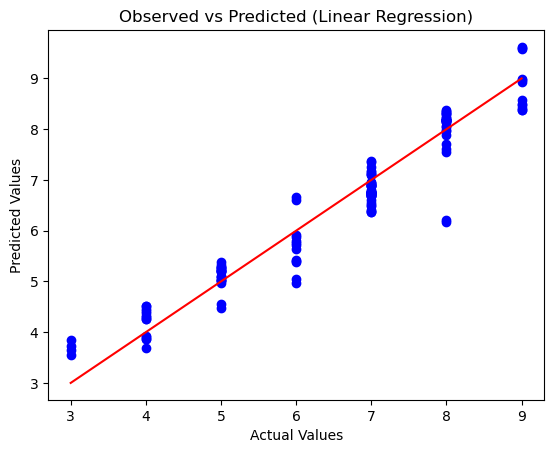

In [29]:
import matplotlib.pyplot as plt

plt.scatter(y_test, lr_pred, color='blue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Observed vs Predicted (Linear Regression)")
plt.show()

In [31]:
print("Intercept:", poly_model.intercept_)
print("Coefficients:", poly_model.coef_)

Intercept: 6.485629435146256
Coefficients: [ 0.          0.09143173 -0.17578142 -0.76038341  0.61519544 -0.06809073
 -0.02548975 -0.23943719 -0.08143772  0.1420358  -0.16707557  0.13738548
 -0.05889711  0.18762129  0.1377114 ]


In [32]:
sample = df_clean.sample(5, random_state=42)
sample

,Student_ID,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score,Conflicts_Over_Social_Media,Addicted_Score,Gender_Male,Academic_Level_High School,Academic_Level_Undergraduate,...,Most_Used_Platform_Snapchat,Most_Used_Platform_TikTok,Most_Used_Platform_Twitter,Most_Used_Platform_VKontakte,Most_Used_Platform_WeChat,Most_Used_Platform_WhatsApp,Most_Used_Platform_YouTube,Affects_Academic_Performance_Yes,Relationship_Status_In Relationship,Relationship_Status_Single
495,496,22,3.8,8.4,6,3,7,True,False,False,...,False,True,False,False,False,False,False,True,False,True
165,166,21,5.4,6.0,6,4,8,True,False,False,...,False,True,False,False,False,False,False,True,True,False
55,56,20,4.9,5.6,6,3,7,False,False,True,...,True,False,False,False,False,False,False,True,False,False
644,645,23,5.3,6.8,6,3,7,False,False,False,...,False,False,True,False,False,False,False,True,True,False
610,611,22,5.4,6.9,6,3,7,False,False,False,...,False,False,False,False,False,False,False,True,True,False


In [1]:
results_clf

NameError: name 'results_clf' is not defined